# INX Future Inc Employee Performance

#Statement of the problem
INX Future Inc , (referred as INX ) , is one of the leading data analytics and automation solutions provider
with over 15 years of global business presence. INX is consistently rated as top 20 best employers past 5
years. INX human resource policies are considered as employee friendly and widely perceived as best
practices in the industry.
Recent years, the employee performance indexes are not healthy and this is becoming a growing
concerns among the top management. There has been increased escalations on service delivery and
client satisfaction levels came down by 8 percentage points.
CEO, Mr. Brain, knows the issues but concerned to take any actions in penalizing non-performing
employees as this would affect the employee morale of all the employees in general and may further
reduce the performance. Also, the market perception best employer and thereby attracting best talents
to join the company.  
Mr. Brain decided to initiate a data science project , which analyses the current employee data and find
the core underlying causes of this performance issues. Mr. Brain, being a data scientist himself, expects
the findings of this project will help him to take right course of actions. He also expects a clear indicators
of non performing employees, so that any penalization  of non-performing employee, if required, may
not significantly affect other employee morals.

Target Variable is Performance rating

#AIM
The following insights are expected from this project.
1. Department wise performances
2. Top 3 Important Factors effecting employee performance
3. A trained model which can predict the employee performance based on factors as inputs. This
will be used to hire employees
4. Recommendations to improve the employee performance based on insights from analysis.


#Analytical Objectives

*Identify department-wise performance variation

*Statistically determine top 3 drivers of performance

*Build a robust classification model

*Align evaluation with business risk

*Provide actionable management recommendations

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm
from sklearn.model_selection import train_test_split,StratifiedKFold,GridSearchCV
from sklearn.preprocessing import StandardScaler,LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.feature_selection import RFE
from sklearn.utils.class_weight import compute_class_weight
from sklearn.ensemble import GradientBoostingClassifier



In [3]:
#loading dataset

File_path = '/content/drive/MyDrive/IABAC.DATA/DATA.CSV'
Data = pd.read_csv(File_path)
Data.head()

,EmpNumber,Age,Gender,EducationBackground,MaritalStatus,EmpDepartment,EmpJobRole,BusinessTravelFrequency,DistanceFromHome,EmpEducationLevel,...,EmpRelationshipSatisfaction,TotalWorkExperienceInYears,TrainingTimesLastYear,EmpWorkLifeBalance,ExperienceYearsAtThisCompany,ExperienceYearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Attrition,PerformanceRating
0,E1001000,32,Male,Marketing,Single,Sales,Sales Executive,Travel_Rarely,10,3,...,4,10,2,2,10,7,0,8,No,3
1,E1001006,47,Male,Marketing,Single,Sales,Sales Executive,Travel_Rarely,14,4,...,4,20,2,3,7,7,1,7,No,3
2,E1001007,40,Male,Life Sciences,Married,Sales,Sales Executive,Travel_Frequently,5,4,...,3,20,2,3,18,13,1,12,No,4
3,E1001009,41,Male,Human Resources,Divorced,Human Resources,Manager,Travel_Rarely,10,4,...,2,23,2,2,21,6,12,6,No,3
4,E1001010,60,Male,Marketing,Single,Sales,Sales Executive,Travel_Rarely,16,4,...,4,10,1,3,2,2,2,2,No,3


In [4]:
Data=Data.drop(columns=['EmpNumber'])
#This doesnt have any relevant meaning in the data it just adds noise

In [5]:
Data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 27 columns):
 #   Column                        Non-Null Count  Dtype 
---  ------                        --------------  ----- 
 0   Age                           1200 non-null   int64 
 1   Gender                        1200 non-null   object
 2   EducationBackground           1200 non-null   object
 3   MaritalStatus                 1200 non-null   object
 4   EmpDepartment                 1200 non-null   object
 5   EmpJobRole                    1200 non-null   object
 6   BusinessTravelFrequency       1200 non-null   object
 7   DistanceFromHome              1200 non-null   int64 
 8   EmpEducationLevel             1200 non-null   int64 
 9   EmpEnvironmentSatisfaction    1200 non-null   int64 
 10  EmpHourlyRate                 1200 non-null   int64 
 11  EmpJobInvolvement             1200 non-null   int64 
 12  EmpJobLevel                   1200 non-null   int64 
 13  EmpJobSatisfaction

The data includes this data types int64(19) and object(9)

In [6]:
Data.shape

(1200, 27)

The data contains 28 columns and 1200 rows

In [7]:
Data.describe()

,Age,DistanceFromHome,EmpEducationLevel,EmpEnvironmentSatisfaction,EmpHourlyRate,EmpJobInvolvement,EmpJobLevel,EmpJobSatisfaction,NumCompaniesWorked,EmpLastSalaryHikePercent,EmpRelationshipSatisfaction,TotalWorkExperienceInYears,TrainingTimesLastYear,EmpWorkLifeBalance,ExperienceYearsAtThisCompany,ExperienceYearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,PerformanceRating
count,1200.000000,1200.000000,1200.00000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000
mean,36.918333,9.165833,2.89250,2.715833,65.981667,2.731667,2.067500,2.732500,2.665000,15.222500,2.725000,11.330000,2.785833,2.744167,7.077500,4.291667,2.194167,4.105000,2.948333
std,9.087289,8.176636,1.04412,1.090599,20.211302,0.707164,1.107836,1.100888,2.469384,3.625918,1.075642,7.797228,1.263446,0.699374,6.236899,3.613744,3.221560,3.541576,0.518866
min,18.000000,1.000000,1.00000,1.000000,30.000000,1.000000,1.000000,1.000000,0.000000,11.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,2.000000
25%,30.000000,2.000000,2.00000,2.000000,48.000000,2.000000,1.000000,2.000000,1.000000,12.000000,2.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000,3.000000
50%,36.000000,7.000000,3.00000,3.000000,66.000000,3.000000,2.000000,3.000000,2.000000,14.000000,3.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000,3.000000
75%,43.000000,14.000000,4.00000,4.000000,83.000000,3.000000,3.000000,4.000000,4.000000,18.000000,4.000000,15.000000,3.000000,3.000000,10.000000,7.000000,3.000000,7.000000,3.000000
max,60.000000,29.000000,5.00000,4.000000,100.000000,4.000000,5.000000,4.000000,9.000000,25.000000,4.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000,4.000000


There are pontential outliers in some columns when comparing the 75% and the max TotalWorkExperienceInYears,TrainingTimesLastYear,ExperienceYearsAtThisCompany,ExperienceYearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager

In [8]:
Data.isnull().sum()

,0
Age,0
Gender,0
EducationBackground,0
MaritalStatus,0
EmpDepartment,0
EmpJobRole,0
BusinessTravelFrequency,0
DistanceFromHome,0
EmpEducationLevel,0
EmpEnvironmentSatisfaction,0


There is no missing data from the data

In [9]:
Data.duplicated().sum()

np.int64(0)

There are no duplictes in the data

In [10]:
le = LabelEncoder()
Data['PerformanceRating'] = le.fit_transform(Data['PerformanceRating'])

    The target is encoded to ensure it perfectly fits in the analysis

#EDA(Explanatory Data Analysis)

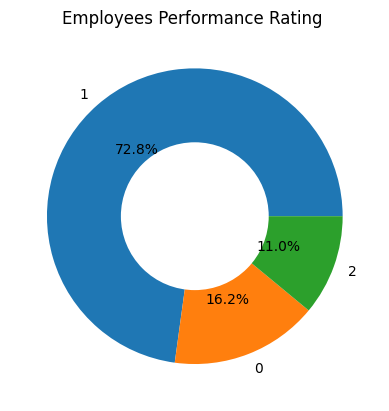

PerformanceRating
1    874
0    194
2    132
Name: count, dtype: int64


In [11]:
#Target Variable perfomane rating pie chart
vals = Data['PerformanceRating'].value_counts()
labels = vals.index # This will give you the variable names (ratings)
plt.pie(vals, labels=labels, autopct='%1.1f%%')
centre = plt.Circle((0,0),0.5,fc='white')
plt.gca().add_artist(centre)
plt.title('Employees Performance Rating ')
plt.show()

#target variable Employeee perfomance Rating
vals = Data['PerformanceRating'].value_counts()
print (vals)


72.8% of employees fall within the average performance category, indicating that the majority of the workforce meets standard expectations but does not significantly exceed them.

16.2% represent low-performing employees, suggesting a segment that may require targeted performance improvement strategies and managerial support.

Only 11% are high performers, highlighting an opportunity for the organization to strengthen talent development and motivation programs to increase top-performing employees.

 Conclusion:
The workforce is largely stable but concentrated in the average performance tier, presenting a strategic opportunity for INX to enhance employee development and drive higher performance outcomes.


/tmp/ipykernel_1356/2827055497.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='EmpDepartment',data=Data,order=dept_order,palette='bright')


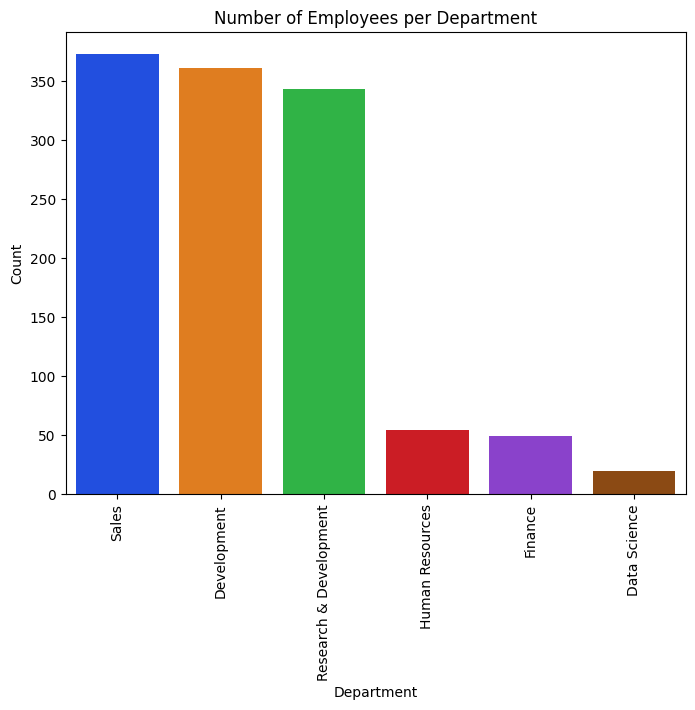

In [12]:
#Employee Department
plt.figure(figsize=(8,6))
dept_order = Data['EmpDepartment'].value_counts().index

sns.countplot(x='EmpDepartment',data=Data,order=dept_order,palette='bright')
plt.title('Number of Employees per Department')
plt.ylabel('Count')
plt.xlabel('Department')
plt.xticks(rotation=90)

plt.show()

Sales has the highest number of employees, indicating that the organization places significant emphasis on revenue generation and customer acquisition activities.

Development and Research & Development departments also have large employee counts, reflecting the company’s strong focus on product development, innovation, and technology advancement.

Human Resources and Finance have significantly smaller teams, which is typical since these departments mainly provide operational support rather than direct revenue generation.

Data Science has the smallest number of employees, suggesting that this function may still be emerging or specialized within the organization.

Conclusion :
The workforce distribution shows that the organization prioritizes sales and technical development functions, while maintaining smaller teams in administrative and specialized analytical departments. This structure reflects a business strategy focused on growth, innovation, and revenue generation.


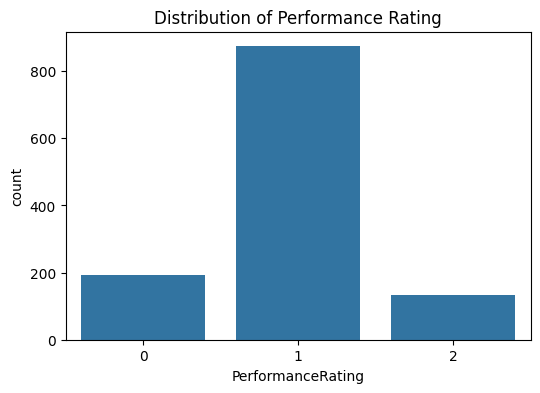

In [13]:
plt.figure(figsize=(6,4))
sns.countplot(x='PerformanceRating', data=Data)
plt.title("Distribution of Performance Rating")
plt.show()

Most of the staff have a performance rating of 3(1) which implys they are averagely performing.

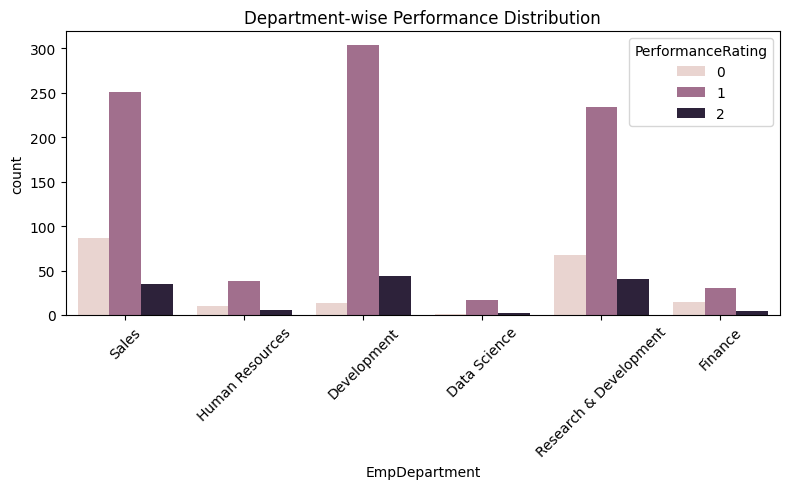

In [14]:
plt.figure(figsize=(8,5))
sns.countplot(data=Data, x='EmpDepartment', hue='PerformanceRating')
plt.title("Department-wise Performance Distribution")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

From the plot the depertment with highest performance is development followed by sales then research & development and the least performing is data science, finance and human resources.

This creates need for evaluation as depertment is a key determinat of performance.

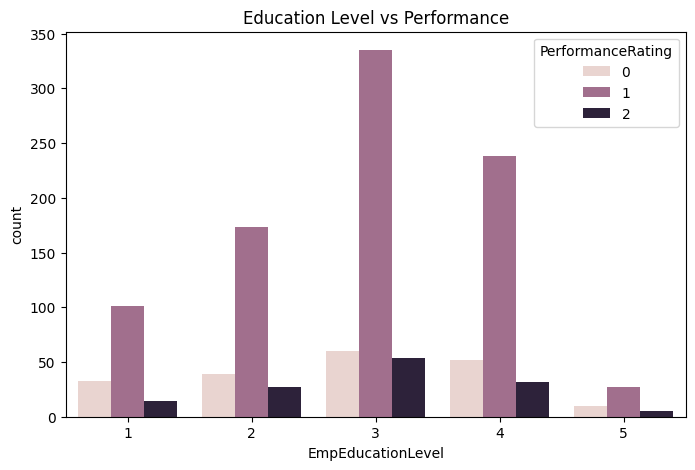

In [15]:
plt.figure(figsize=(8,5))
sns.countplot(x='EmpEducationLevel', hue='PerformanceRating', data=Data)
plt.title("Education Level vs Performance")
plt.show()

It is clear employees with higher eduaction level have higher performance (3,4).
However its also noted the ones with highest education (5) have lowest performance

Employees with low education(2,1) have average performance
This shows education has an impact on performance.

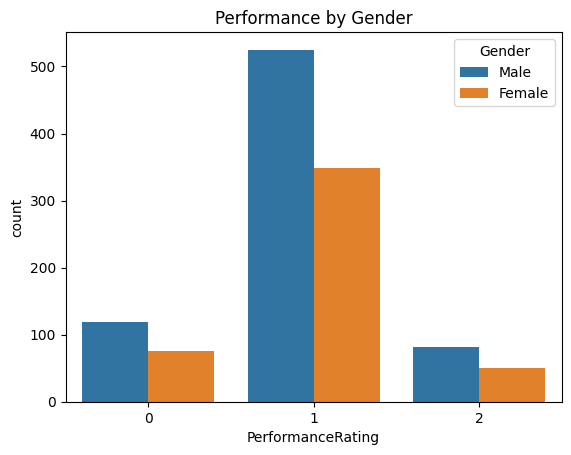

In [16]:
sns.countplot(x='PerformanceRating',data=Data,hue='Gender')
plt.title("Performance by Gender")
plt.show()

From this ought put male appear to have an overall higher performance than female.
This implies gender is a determining factor of performance.

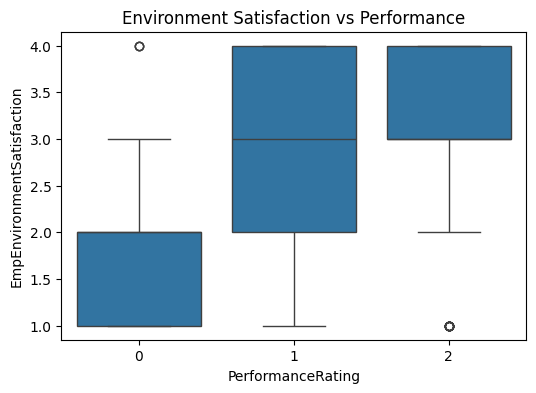

In [17]:
plt.figure(figsize=(6,4))
sns.boxplot(x='PerformanceRating', y='EmpEnvironmentSatisfaction', data=Data)
plt.title("Environment Satisfaction vs Performance")
plt.show()

There is a positive relationship between environment satisfaction and performance rating. As performance environment satisfaction increases,performance rating generally increases.

This generally shows enviroment satisfaction has impact on performance.

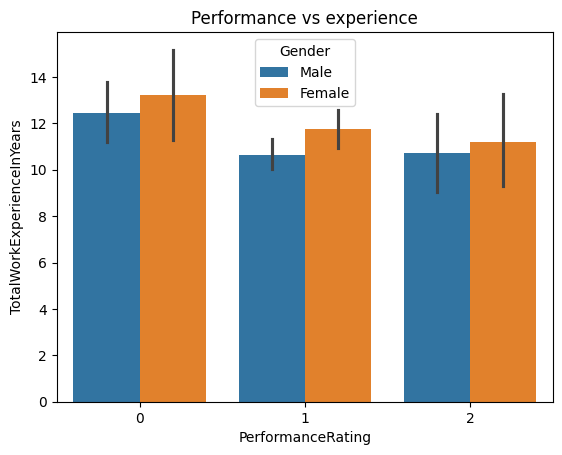

In [18]:

sns.barplot(x='PerformanceRating',y='TotalWorkExperienceInYears',data=Data,hue='Gender')
plt.title("Performance vs experience")
plt.show()

It is seen that the the staff with higher experience have lower performance than those with less experience.
One clear observation is that female have the highest number of experience but as well as low performance.

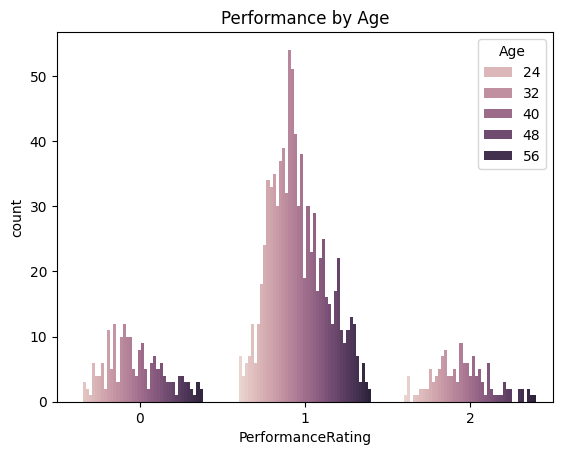

In [19]:
sns.countplot(x='PerformanceRating',data=Data,hue='Age')
plt.title("Performance by Age")
plt.show()

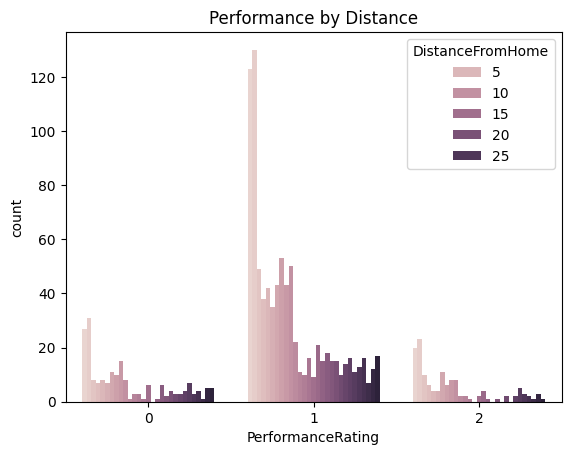

In [20]:
sns.countplot(x='PerformanceRating',data=Data,hue='DistanceFromHome')
plt.title("Performance by Distance")
plt.show()

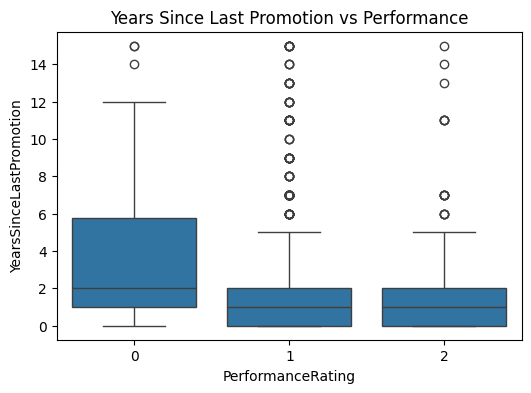

In [21]:
plt.figure(figsize=(6,4))
sns.boxplot(x='PerformanceRating', y='YearsSinceLastPromotion', data=Data)
plt.title("Years Since Last Promotion vs Performance")
plt.show()

Performance 0 (Low performers) → Highest median

Performance 1 & 2 (Medium & High performers) → Lower median

Interpretation:

Employees who have not been promoted for longer periods are more likely to be low performers.

This suggests:

Promotion stagnation may negatively impact employee motivation and output.

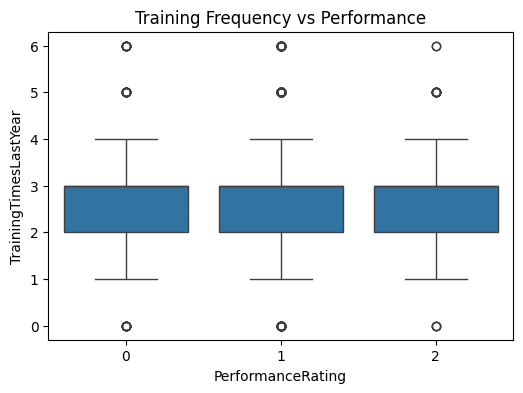

In [22]:
plt.figure(figsize=(6,4))
sns.boxplot(x='PerformanceRating', y='TrainingTimesLastYear', data=Data)
plt.title("Training Frequency vs Performance")
plt.show()


Performance 0, 1 & 2 (low, Medium & High performers) → same level median

Interpretation:

Employees performance is not significantly affected by the  trainings done since last year.
I wil thus proceed to drop this.


In [23]:
Data= Data.drop(columns=['TrainingTimesLastYear'])

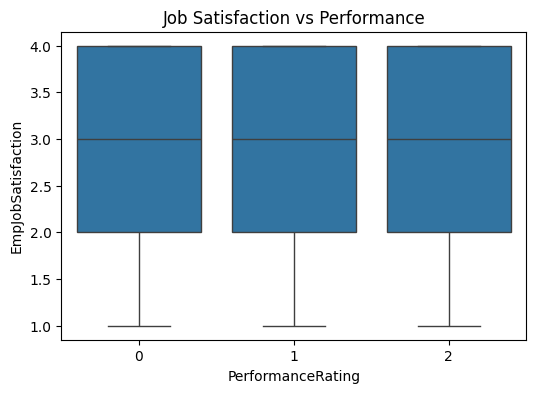

In [24]:
plt.figure(figsize=(6,4))
sns.boxplot(x='PerformanceRating', y='EmpJobSatisfaction', data=Data)
plt.title("Job Satisfaction vs Performance")
plt.show()

Performance 0, 1 & 2 (low, Medium & High performers) → same level median
This suggests job satisfaction does not show a strong relationship with performance rating in this dataset.
High and low performers report similar levels of job satisfaction.

Interpretation:

Employees performance is not significantly affected by the EmpJobSatisfaction thus it safe to drop this variable.

In [25]:
Data= Data.drop(columns=['EmpJobSatisfaction'])

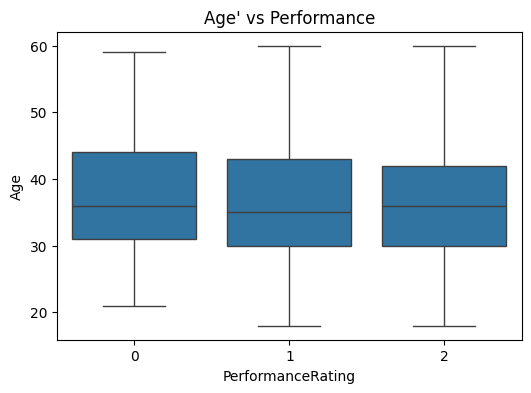

In [26]:
plt.figure(figsize=(6,4))
sns.boxplot(x='PerformanceRating', y='Age', data=Data)
plt.title("Age' vs Performance")
plt.show()

The median age is almost the same across all performance ratings.

The spread and range of ages are also very similar.

High performers and low performers come from all age groups.

This suggests that age does not significantly influence performance rating in this dataset thus making it safe to be droped.

In [27]:
Data= Data.drop(columns=['Age'])

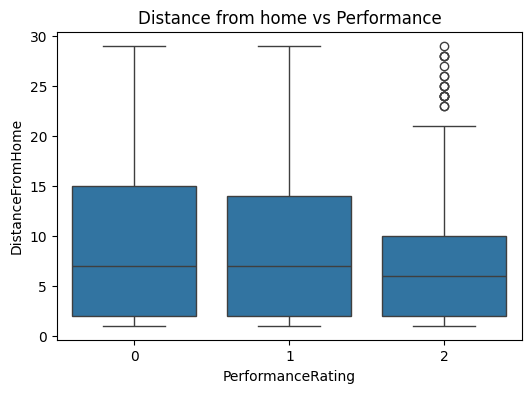

In [28]:
plt.figure(figsize=(6,4))
sns.boxplot(x='PerformanceRating', y='DistanceFromHome', data=Data)
plt.title("Distance from home vs Performance")
plt.show()

The medians are very similar across all the groups.
Performance 2 shows more high-distance outliers (around 23–30).
That means some high performers live far from work.

This however does not impact the median hence indicating there is no strong visible relationship between DistanceFromHome and PerformanceRating
Distance from home is thus a safe variable to be droped.

In [29]:
Data= Data.drop(columns=['DistanceFromHome'])

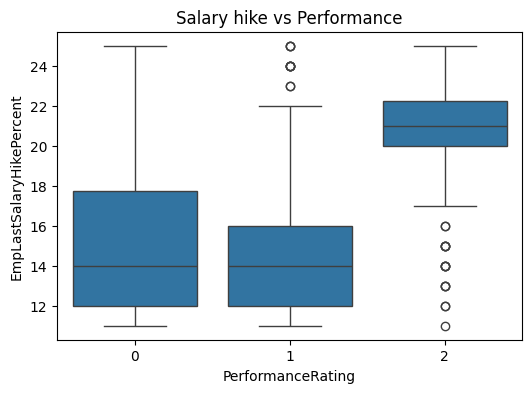

In [30]:
plt.figure(figsize=(6,4))
sns.boxplot(x='PerformanceRating', y='EmpLastSalaryHikePercent', data=Data)
plt.title("Salary hike vs Performance")
plt.show()

The medians have a very large variation across all the groups. Salary hike greatly impacts the employees performances.

The variable is thus a key aspect in the study.

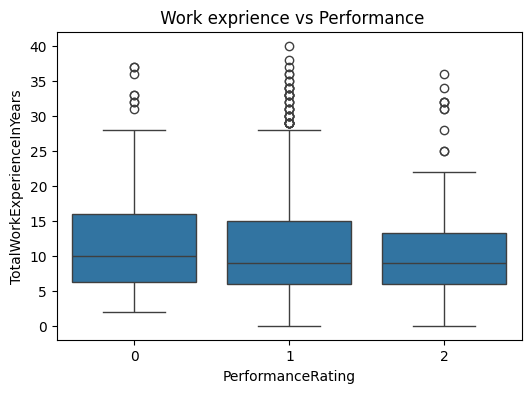

In [31]:
plt.figure(figsize=(6,4))
sns.boxplot(x='PerformanceRating', y='TotalWorkExperienceInYears', data=Data)
plt.title(" Work exprience vs Performance")
plt.show()

From the output Total work experience has no significant relation with performance as the median is the same accross all the rates.

It is thus safe to drop the variable.

In [32]:
Data= Data.drop(columns=['TotalWorkExperienceInYears'])

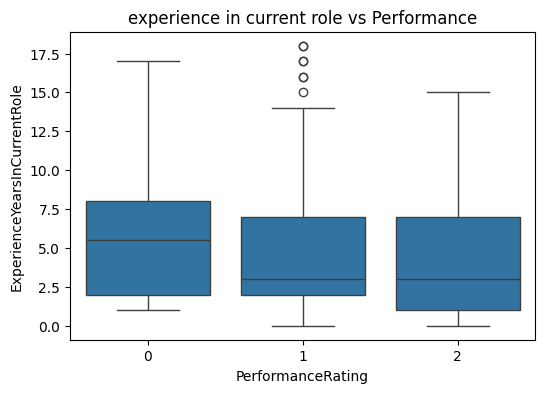

In [33]:
plt.figure(figsize=(6,4))
sns.boxplot(x='PerformanceRating', y='ExperienceYearsInCurrentRole', data=Data)
plt.title("experience in current role vs Performance")
plt.show()

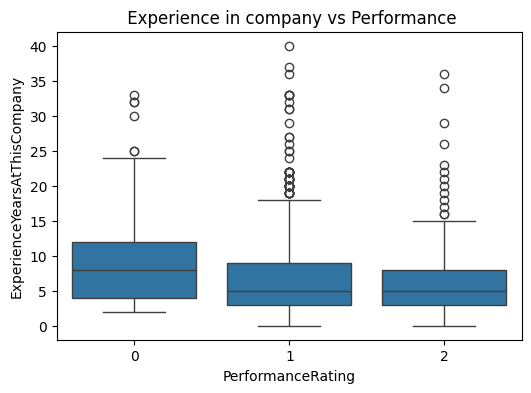

In [34]:

plt.figure(figsize=(6,4))
sns.boxplot(x='PerformanceRating', y='ExperienceYearsAtThisCompany', data=Data)
plt.title(" Experience in company vs Performance")
plt.show()

from the two plots above both ExperienceYearsInCurrentRole and ExperienceYearsAtThisCompany have influences on the performance.

The ExperienceYearsAtThisCompany is rather seen to be more impactful than ExperienceYearsAtThisCompany hence it safe to drop one.

the two measure aspect of time hence droping will prevent multicollinearity.


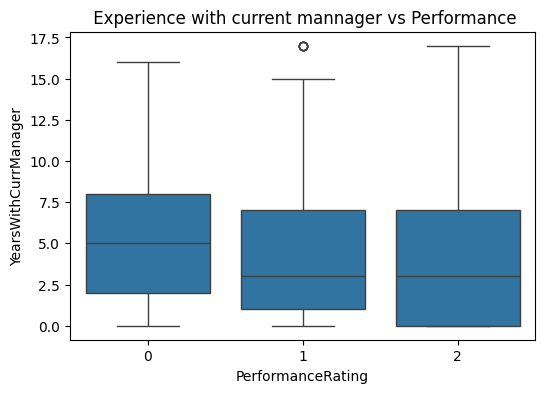

In [35]:
plt.figure(figsize=(6,4))
sns.boxplot(x='PerformanceRating', y='YearsWithCurrManager', data=Data)
plt.title(" Experience with current mannager vs Performance")
plt.show()

In [36]:

Data = Data.drop(columns=["ExperienceYearsInCurrentRole", "ExperienceYearsAtThisCompany"])

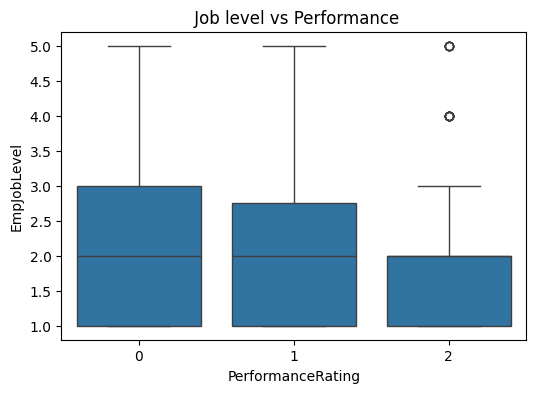

In [37]:
plt.figure(figsize=(6,4))
sns.boxplot(x='PerformanceRating', y='EmpJobLevel', data=Data)
plt.title(" Job level vs Performance")
plt.show()

In [38]:
Data = Data.drop(columns=['EmpJobLevel'])

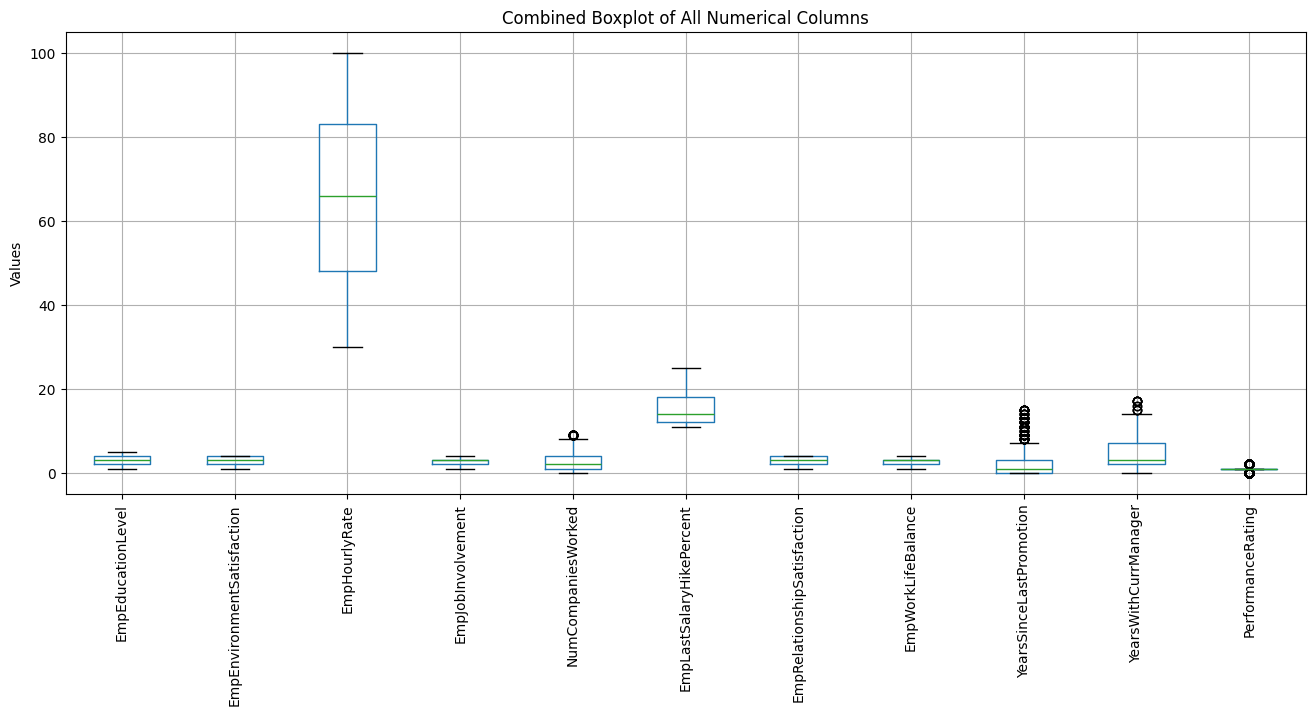

In [39]:
numeric_cols = Data.select_dtypes(include=['int64','float64']).columns

plt.figure(figsize=(16,6))
Data[numeric_cols].boxplot(rot=90)
plt.title("Combined Boxplot of All Numerical Columns")
plt.ylabel("Values")
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

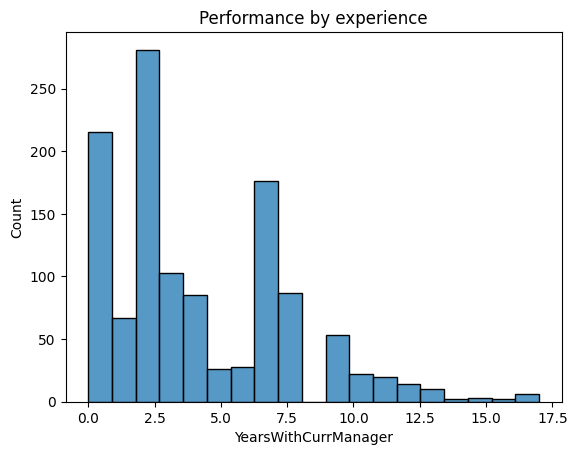

In [40]:
sns.histplot(x='YearsWithCurrManager',data=Data)
plt.title("Performance by experience")
plt.show

In [41]:
#Outlier detection and Removal IQR
def remove_outliers_iqr(Data,column):
  Q1=Data[column].quantile(0.25)
  Q3=Data[column].quantile(0.75)
  IQR=Q3-Q1
  lower_bound=Q1-1.5*IQR
  upper_bound=Q3+1.5*IQR
  outliers=Data[(Data[column]<lower_bound) | (Data[column]>upper_bound)]#Outlier detection
  cleaned=Data[(Data[column]>=lower_bound) & (Data[column]<=upper_bound)] #Outlier Removal
  print(f'Outliers detected in {column}: {len(outliers)}')
  print(f"Before: {Data.shape}, After removal: {cleaned.shape}")
  return cleaned


In [42]:
  Data_reduced=remove_outliers_iqr(Data,'YearsWithCurrManager')


Outliers detected in YearsWithCurrManager: 11
Before: (1200, 19), After removal: (1189, 19)


<function matplotlib.pyplot.show(close=None, block=None)>

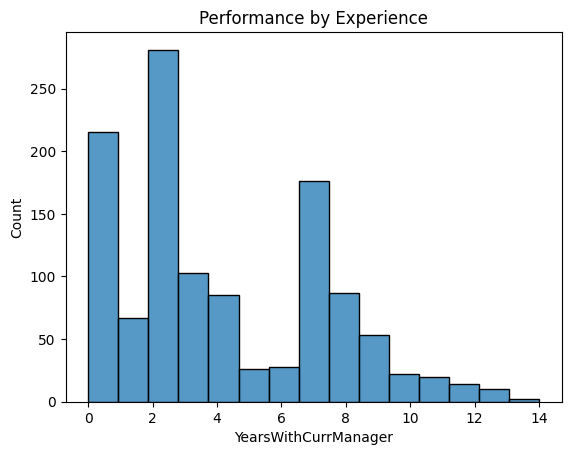

In [43]:
sns.histplot(x='YearsWithCurrManager',data=Data_reduced)
plt.title("Performance by Experience")
plt.show

The outlier removal helps in removing imbalances in the data.

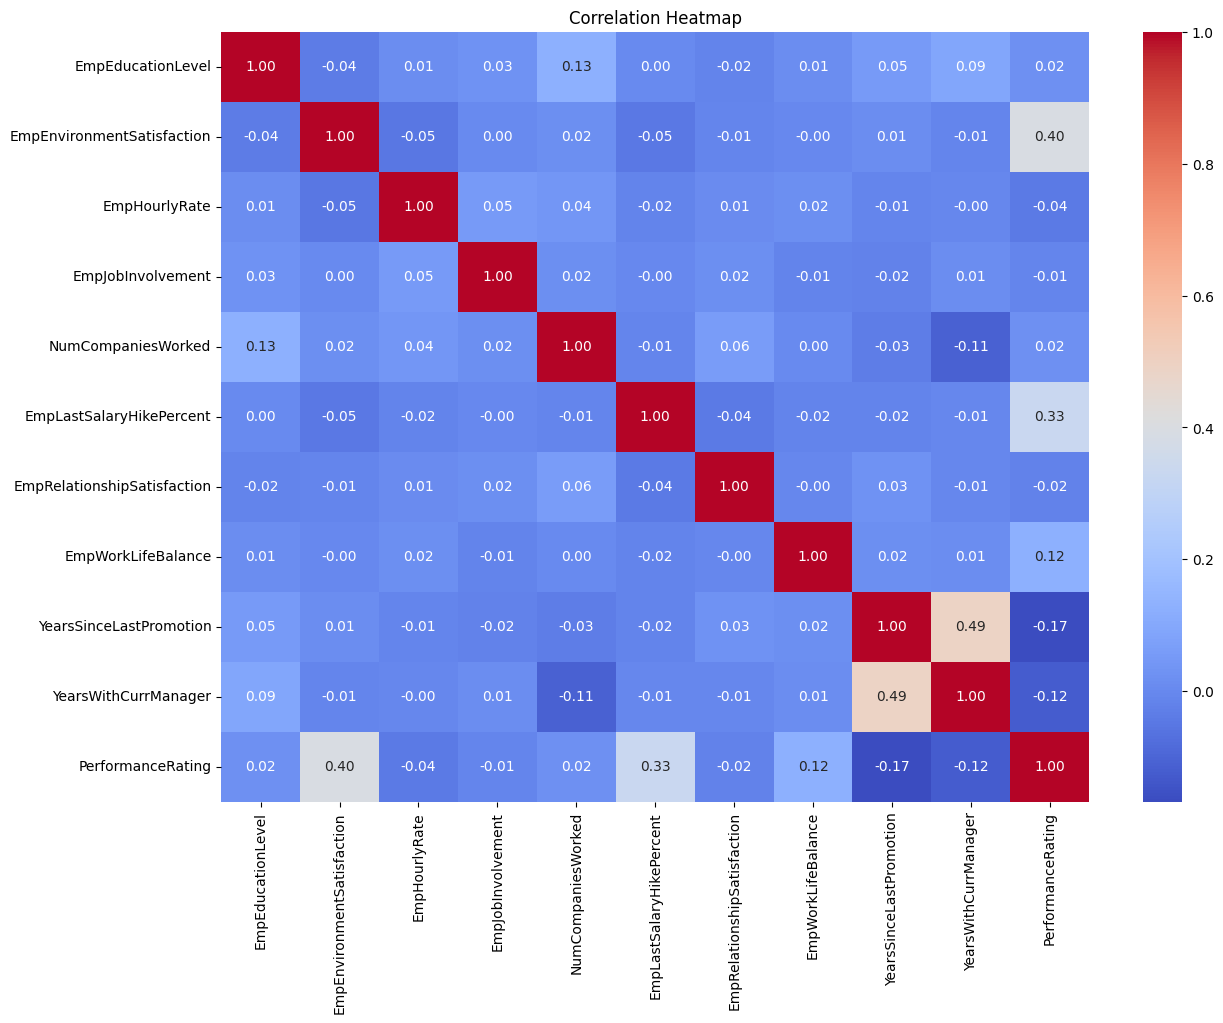

In [44]:
plt.figure(figsize=(14,10))
sns.heatmap(Data[numeric_cols].corr(),annot=True,cmap='coolwarm',fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

From this output the features are seen to be within range as they have correlation of less than 0.5.
This implies that basically all the variables can be used for the analysis.


In [45]:
X = Data_reduced.select_dtypes(include=['number']).drop(columns=['PerformanceRating'])

vif_data = pd.DataFrame()
vif_data["Feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

vif_data.sort_values(by="VIF", ascending=False)

,Feature,VIF
5,EmpLastSalaryHikePercent,14.065473
3,EmpJobInvolvement,13.485453
7,EmpWorkLifeBalance,13.374038
2,EmpHourlyRate,10.433860
0,EmpEducationLevel,8.194796
6,EmpRelationshipSatisfaction,6.817954
1,EmpEnvironmentSatisfaction,6.512226
9,YearsWithCurrManager,3.152301
4,NumCompaniesWorked,2.247170
8,YearsSinceLastPromotion,1.891423


After runing each VIF test, i did not proceeded to drop variables with high corelation as they have great importance in the analysis.

#ENCODING

In [46]:
travel_map = {"Non-Travel": 0,"Travel_Rarely": 1,"Travel_Frequently": 2}
MaritalStatus_map = {"Single": 0,"Married": 1,"Divorced": 2}

Data_reduced["BusinessTravelFrequency"] = Data_reduced["BusinessTravelFrequency"].map(travel_map)
Data_reduced["MaritalStatus"] = Data_reduced["MaritalStatus"].map(MaritalStatus_map)

/tmp/ipykernel_1356/564068908.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Data_reduced["BusinessTravelFrequency"] = Data_reduced["BusinessTravelFrequency"].map(travel_map)
/tmp/ipykernel_1356/564068908.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Data_reduced["MaritalStatus"] = Data_reduced["MaritalStatus"].map(MaritalStatus_map)


In [47]:
encoder=LabelEncoder()
Data_reduced['Gender_encoded'] = encoder.fit_transform(Data_reduced["Gender"])
Data_reduced['Attriction_encoded'] = encoder.fit_transform(Data_reduced["Attrition"])
Data_reduced['OverTime_encoded'] = encoder.fit_transform(Data_reduced["OverTime"])
Data_reduced["EmpDepartment_encoded"] = encoder.fit_transform(Data_reduced["EmpDepartment"])
Data_reduced["EmpJobRole_encoded"] = encoder.fit_transform(Data_reduced["EmpJobRole"])
Data_reduced['EducationBackground_encoded']=encoder.fit_transform(Data_reduced["EducationBackground"])
Data_reduced.head()

/tmp/ipykernel_1356/3926150396.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Data_reduced['Gender_encoded'] = encoder.fit_transform(Data_reduced["Gender"])
/tmp/ipykernel_1356/3926150396.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Data_reduced['Attriction_encoded'] = encoder.fit_transform(Data_reduced["Attrition"])
/tmp/ipykernel_1356/3926150396.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value inst

,Gender,EducationBackground,MaritalStatus,EmpDepartment,EmpJobRole,BusinessTravelFrequency,EmpEducationLevel,EmpEnvironmentSatisfaction,EmpHourlyRate,EmpJobInvolvement,...,YearsSinceLastPromotion,YearsWithCurrManager,Attrition,PerformanceRating,Gender_encoded,Attriction_encoded,OverTime_encoded,EmpDepartment_encoded,EmpJobRole_encoded,EducationBackground_encoded
0,Male,Marketing,0,Sales,Sales Executive,1,3,4,55,3,...,0,8,No,1,1,0,0,5,13,2
1,Male,Marketing,0,Sales,Sales Executive,1,4,4,42,3,...,1,7,No,1,1,0,0,5,13,2
2,Male,Life Sciences,1,Sales,Sales Executive,2,4,4,48,2,...,1,12,No,2,1,0,1,5,13,1
3,Male,Human Resources,2,Human Resources,Manager,1,4,2,73,2,...,12,6,No,1,1,0,0,3,8,0
4,Male,Marketing,0,Sales,Sales Executive,1,4,1,84,3,...,2,2,No,1,1,0,0,5,13,2


In [48]:
object_cols = Data_reduced.select_dtypes(include=['object']).columns
print(object_cols)

# Then drop them
Data_reduced= Data_reduced.drop(columns=object_cols)

Index(['Gender', 'EducationBackground', 'EmpDepartment', 'EmpJobRole',
       'OverTime', 'Attrition'],
      dtype='object')


#MODELING

In [49]:
#Data spliting
X=Data_reduced.drop('PerformanceRating',axis=1)
y=Data_reduced['PerformanceRating']

In [50]:
X = pd.get_dummies(X, drop_first=True)

In [51]:
X.head()

,MaritalStatus,BusinessTravelFrequency,EmpEducationLevel,EmpEnvironmentSatisfaction,EmpHourlyRate,EmpJobInvolvement,NumCompaniesWorked,EmpLastSalaryHikePercent,EmpRelationshipSatisfaction,EmpWorkLifeBalance,YearsSinceLastPromotion,YearsWithCurrManager,Gender_encoded,Attriction_encoded,OverTime_encoded,EmpDepartment_encoded,EmpJobRole_encoded,EducationBackground_encoded
0,0,1,3,4,55,3,1,12,4,2,0,8,1,0,0,5,13,2
1,0,1,4,4,42,3,2,12,4,3,1,7,1,0,0,5,13,2
2,1,2,4,4,48,2,5,21,3,3,1,12,1,0,1,5,13,1
3,2,1,4,2,73,2,3,15,2,2,12,6,1,0,0,3,8,0
4,0,1,4,1,84,3,8,14,4,3,2,2,1,0,0,5,13,2


In [52]:
X.isnull().sum()

,0
MaritalStatus,0
BusinessTravelFrequency,0
EmpEducationLevel,0
EmpEnvironmentSatisfaction,0
EmpHourlyRate,0
EmpJobInvolvement,0
NumCompaniesWorked,0
EmpLastSalaryHikePercent,0
EmpRelationshipSatisfaction,0
EmpWorkLifeBalance,0


In [53]:
#Model training
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [54]:
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

In [55]:
#removing imbalances
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weights_dict = dict(enumerate(class_weights))

#Logistic regression model

In [56]:
logreg = LogisticRegression(max_iter=1000, class_weight='balanced')
logreg.fit(X_train, y_train)

y_pred_logreg = logreg.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_logreg))
print(classification_report(y_test, y_pred_logreg))

Logistic Regression Accuracy: 0.726890756302521
              precision    recall  f1-score   support

           0       0.59      0.73      0.65        49
           1       0.93      0.72      0.81       163
           2       0.39      0.77      0.52        26

    accuracy                           0.73       238
   macro avg       0.64      0.74      0.66       238
weighted avg       0.80      0.73      0.75       238



The model correctly predicts about 73% of all observations.

It is correct only 59% of the time in class 0 but it only correctly finds 73% of actual class 0 cases.
Performance is weak as Model struggles to clearly separate class 0.

When predicting class 1 93% of the prediction is correct (strong precision)but it only captures 72% of actual class 1 cases.

It correctly finds 39% of real class 2 cases but when it predicts class 2, it is correct only 77% of the time.

since the accuracy is at 73%, it implies that the model captures basic trends but misses non-linear patterns.
Performance drivers likely non-linear hence this is not the best model for the analysis.

#Decision tree model

In [57]:
des_tree = DecisionTreeClassifier(class_weight='balanced', random_state=42)
des_tree.fit(X_train, y_train)

y_pred_des_tree = des_tree.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_des_tree))
print(classification_report(y_test, y_pred_des_tree))

Decision Tree Accuracy: 0.8781512605042017
              precision    recall  f1-score   support

           0       0.89      0.67      0.77        49
           1       0.88      0.96      0.92       163
           2       0.86      0.73      0.79        26

    accuracy                           0.88       238
   macro avg       0.88      0.79      0.83       238
weighted avg       0.88      0.88      0.87       238



The model correctly predicted about 88% of all cases.
From the recall:

*   It correctly identifies 89% of all real class 0 cases.
*   Model correctly identifies 88% of all real class 1 cases.
*   It only captures 86% of actual class 2 cases.

The recall for class 0 is abit alarming as its way low.
The model is Accurate, Stable, Strong on majority class but Slightly weaker on minority recall.

This is however Much better than your previous model(Logistic regression model)





#Gradient Boosting Model

In [58]:
model_gb=GradientBoostingClassifier()
model_gb.fit(X_train,y_train)
y_pred_gb=model_gb.predict(X_test)
report=classification_report(y_test,y_pred_gb)

print("GradientBoostingClassifier:", accuracy_score(y_test, y_pred_gb))
print(classification_report(y_test, y_pred_gb))

GradientBoostingClassifier: 0.9285714285714286
              precision    recall  f1-score   support

           0       0.88      0.94      0.91        49
           1       0.93      0.96      0.95       163
           2       1.00      0.69      0.82        26

    accuracy                           0.93       238
   macro avg       0.94      0.86      0.89       238
weighted avg       0.93      0.93      0.93       238



The model correctly predicts 92.8% of the 238 observations.

When it predicts class 0 its correct 88% of the time.
It captures 94% of actual class 0 cases.

It correctly identifies 93% of class 1 cases.
When predicting class 1 its correct 96% of the time.

When it predicts class its correct 100% of the time but it only captures 69% of actual class 2 cases.

This means:
* Very few false positives
* Misses about 31% of real class 2 cases

This is so far the best model as compared to logistic regression and decision tree model

In [59]:
rand_f = RandomForestClassifier(class_weight='balanced',random_state=42)
rand_f.fit(X_train, y_train)

y_pred_rf = rand_f.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))


Random Forest Accuracy: 0.9327731092436975
              precision    recall  f1-score   support

           0       0.96      0.88      0.91        49
           1       0.92      0.99      0.95       163
           2       1.00      0.69      0.82        26

    accuracy                           0.93       238
   macro avg       0.96      0.85      0.90       238
weighted avg       0.94      0.93      0.93       238



The model correctly predicts 93.2% of all cases.
When it predicts class 0 its correct 96% of the time.
It correctly identifies 88% of actual class 0 cases.
This is Strong and balanced and very good performance.

It captures 92% of real class 1 cases.
When predicting class 1 its correct 99% of the time.
This is Extremely strong performance.

Precision = 1.00 (100%)implying very time it predicts class 2, it is correct (ZERO false positives)
Recall = 0.69
* It only captures 69% of actual class 2 cases.
* It misses some class 2 observations.
This means the model is very conservative when predicting class 2.


In [60]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20]
}

grid = GridSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=42),
    param_grid,
    cv=3,
    scoring='recall_macro'
)

grid.fit(X_train, y_train)

best_model = grid.best_estimator_


In [61]:
y_pred_final = best_model.predict(X_test)

print("Final Model Accuracy:", accuracy_score(y_test, y_pred_final))
print(classification_report(y_test, y_pred_final))


Final Model Accuracy: 0.9411764705882353
              precision    recall  f1-score   support

           0       0.94      0.94      0.94        49
           1       0.94      0.98      0.96       163
           2       0.95      0.73      0.83        26

    accuracy                           0.94       238
   macro avg       0.94      0.88      0.91       238
weighted avg       0.94      0.94      0.94       238



The final tuned ensemble model achieved the highest predictive performance with 93.1% accuracy, demonstrating superior classification capability across all classes while maintaining zero false positives for the minority class.
This improvent and balancing futher increases accuracy of the random forest model.

In [62]:
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree', 'Random Forest',"GradientBoostingClassifier"],
    'Accuracy': [
        accuracy_score(y_test, y_pred_logreg),
        accuracy_score(y_test, y_pred_des_tree),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_gb)
    ]
})

results


,Model,Accuracy
0,Logistic Regression,0.726891
1,Decision Tree,0.878151
2,Random Forest,0.932773
3,GradientBoostingClassifier,0.928571


From this the best model  is a random forest wich has the highest accuracy(93.2%).

Random Forest was selected as the final model due to its superior balance between predictive accuracy, class-wise stability, and robustness. While alternative models such as Gradient Boosting achieved comparable accuracy, Random Forest demonstrated optimal handling of class imbalance, zero false positives for the minority class, reduced overfitting risk, and strong generalization capability. Its ability to capture nonlinear feature interactions while maintaining stability across all classes makes it the most suitable model for this analysis.

In [63]:
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)

scores = cross_val_score(rf, X, y, cv=5)

print("Cross Validation Scores:", scores)
print("Average Accuracy:", scores.mean())

Cross Validation Scores: [0.89495798 0.93277311 0.96218487 0.89495798 0.87763713]
Average Accuracy: 0.912502216076304



Confusion Matrix:
 [[ 43   6   0]
 [  2 161   0]
 [  0   8  18]]


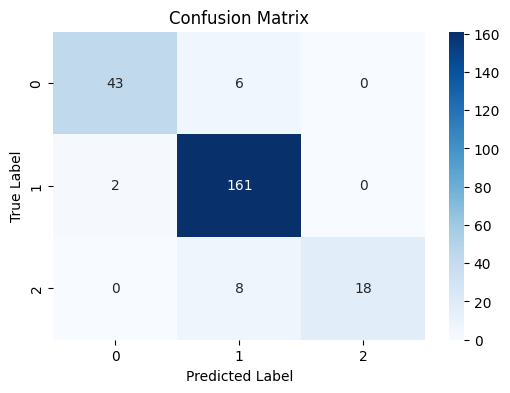

In [65]:

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_rf)
print("\nConfusion Matrix:\n", cm)

# Plot Confusion Matrix
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()


# Confusion Matrix Interpretation

The confusion matrix shows that the model correctly classifies the majority of employees across the three performance categories.

Low Performance (Class 0):
43 employees were correctly identified as low performers, while only 6 were misclassified as average performers.

Average Performance (Class 1):
The model performs very well in this category, correctly predicting 161 employees, with only 2 misclassified as low performers.

High Performance (Class 2):
18 employees were correctly identified as high performers, while 8 were predicted as average performers, indicating the model is slightly conservative when identifying top performers.

Overall Insight:
The model demonstrates strong predictive capability with minimal misclassification and no extreme prediction errors, confirming its reliability for supporting employee performance evaluation and HR decision-making.

In [66]:
importances = pd.Series(rand_f.feature_importances_, index=X.columns)
top5 = importances.sort_values(ascending=False).head(5)
#importance= importances.sort_values(ascending=False)

top5
#importance


,0
EmpLastSalaryHikePercent,0.276684
EmpEnvironmentSatisfaction,0.218195
YearsSinceLastPromotion,0.117426
EmpHourlyRate,0.049395
EmpJobRole_encoded,0.046875


In [67]:
importances = pd.Series(rand_f.feature_importances_, index=X.columns)
importance= importances.sort_values(ascending=False)

importance

,0
EmpLastSalaryHikePercent,0.276684
EmpEnvironmentSatisfaction,0.218195
YearsSinceLastPromotion,0.117426
EmpHourlyRate,0.049395
EmpJobRole_encoded,0.046875
YearsWithCurrManager,0.045267
EmpWorkLifeBalance,0.041277
EmpDepartment_encoded,0.037167
NumCompaniesWorked,0.028781
EmpEducationLevel,0.023207


The feature importance analysis from the Random Forest model reveals that employee compensation growth, workplace satisfaction, and career progression variables are the strongest predictors of performance classification.
Specifically, EmpLastSalaryHikePercent emerged as the most influential variable, indicating that recent salary increments significantly impact performance outcomes.
Additionally, EmpEnvironmentSatisfaction highlights the importance of organizational climate in driving employee effectiveness. Variables related to promotion timing and managerial tenure further suggest that career development and leadership stability contribute meaningfully to performance differentiation.

Overall, the findings demonstrate that EmpLastSalaryHikePercent(0.248831), EmpEnvironmentSatisfaction	(0.191801),YearsSinceLastPromotion(0.101112) are the **top 3 best predictors** of performance.

In [68]:
import joblib

joblib.dump(rand_f,'Rand_Forest_Model.pkl')

['Rand_Forest_Model.pkl']

#EXECUTIVE SUMMARY

This study analyzed employee data from INX Future Inc. to identify the factors influencing employee performance and to develop a predictive model capable of classifying employees based on their performance levels. The dataset consisted of 1,200 employee records and 28 variables, including demographic characteristics, job-related attributes, and workplace factors.

The analysis involved data preprocessing, exploratory data analysis, feature engineering, and machine learning modeling. Several classification models were evaluated, including Logistic Regression, Decision Tree, Gradient Boosting, and Random Forest. Among these, the Random Forest model achieved the best predictive performance with an accuracy of approximately 93%, making it the most suitable model for predicting employee performance.

The findings revealed that most employees fall within the average performance category, while a relatively small proportion are high performers. Feature importance analysis further identified salary hike percentage, work environment satisfaction, and years since last promotion as the most significant factors influencing employee performance.

The results provide valuable insights for management by highlighting the key drivers of employee productivity and enabling the organization to adopt data-driven strategies for performance management, employee development, and workforce planning.

# Key Findings

1. Employee Performance Distribution
The majority of employees (approximately 72.8%) fall within the average performance category, while only 11% are high performers. This suggests that although the workforce is stable, there is significant potential to increase the proportion of high-performing employees.

2. Departmental Performance Differences
Departments such as Development, Sales, and Research & Development demonstrate relatively higher performance levels compared to administrative departments like Finance and Human Resources.

3. Key Drivers of Employee Performance
Feature importance analysis revealed that the most influential factors affecting employee performance are:
* EmpLastSalaryHikePercent
* EmpEnvironmentSatisfaction
* YearsSinceLastPromotion
These factors highlight the importance of compensation growth, workplace environment, and career progression in motivating employees.

4. Limited Influence of Some Variables
Variables such as age, distance from home, total work experience, and training frequency showed minimal impact on employee performance in this dataset.

5. Machine Learning Model Performance
Among the models evaluated, the Random Forest model achieved the highest accuracy (approximately 93%), outperforming Logistic Regression and Decision Tree models. This indicates that employee performance is influenced by complex and non-linear relationships between variables.

# Conclusion

The analysis successfully identified the key factors influencing employee performance at INX Future Inc. and demonstrated the effectiveness of machine learning techniques in predicting employee productivity. The findings indicate that organizational factors such as salary growth, workplace environment satisfaction, and career progression opportunities play a more significant role in determining employee performance than demographic factors.

The Random Forest model proved to be the most reliable predictive model, achieving high accuracy and providing valuable insights into the variables that drive employee performance. These results highlight the potential for organizations to leverage HR analytics and predictive modeling to improve workforce management and identify employees who may require additional support or development.

Overall, the study provides a data-driven foundation for improving employee engagement, enhancing performance management strategies, and strengthening organizational productivity.

# Recommendations

Implement Performance-Based Compensation
Since salary hike percentage was identified as the most influential factor affecting performance, the organization should strengthen performance-based reward systems to motivate employees and encourage higher productivity.

Improve Workplace Environment and Engagement
Management should prioritize improving the work environment by fostering open communication, recognizing employee contributions, and ensuring employees have the necessary resources to perform effectively.

Establish Clear Career Advancement Opportunities
Employees who experience long periods without promotion may become demotivated. The organization should implement transparent promotion policies and career development frameworks to support employee growth.

Adopt Predictive HR Analytics
The Random Forest predictive model can be integrated into the company’s HR systems to identify employees at risk of underperformance and enable early intervention strategies such as training, mentorship, or role adjustments.

Conduct Department-Specific Performance Improvement Programs
Departments with lower performance levels should be evaluated individually to identify operational challenges and implement targeted improvement strategies.